## Lab Exercise Week \#5: Regression and SVM in Machine Learning

### Objective:
The goal of this lab exercise is to understand Linear Regression, Logistic Regression, SVMs and their application in machine learning. You will apply each of the mentioned regression models to the various datasest and use them to make predictions.

### Datasets:
For this lab exercise, you'll use the bike_sharing.csv, AthleteSelection.csv, HotelRevHelpfulnessV2.csv and weightV2.csv datasets from Brightspace.

### Libraries:
`scikit-learn` provides implementations of Linear and Logistic regression,  a gradient descent regressor and several flavours of a support vector classifier. You can find information on SVMs in sklearn here: https://scikit-learn.org/stable/modules/svm.html

### Tasks:

#### 1). Linear Regression:
<ul>
<li>Import all needed libraries.</li>
<li>Load the weightV2.csv dataset.</li>
<li>Explore the dataset to understand its structure and features.</li>
<li>Select approprate features for a your model.</li>
<li>Fit a linear regression model, make predictions and plot the prediction line on a scatter plot.</li>
</ul>

In [58]:
import pandas as pd
import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
# don't need to craete form scratch just cerat an instance for each mode you need
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler # for scaling data -- normalization also MinMax + Robust scaler
# standard scaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error




In [59]:
import pandas as pd
from sklearn.linear_model import SGDRegressor
weight_pd = pd.read_csv('weightV2.csv')
weight_pd.head()
# weight_pd.shape
# input = waist 
# output = weight

,Weight,Waist
0,154.25,85.2
1,173.25,83.0
2,154.00,87.9
3,184.75,86.4
4,184.25,100.0


In [60]:
# define inptu putput - y = target valriable
y = weight_pd.pop('Weight').values # target values of model - name of df and name of column .values means it is an array for all values of weight... will eb removed from df
X = weight_pd.values # wil ahve waist values
y.shape

(251,)

In [61]:
from sklearn.linear_model import LinearRegression
# crteate an istance for LR model...
# take X - input features (waist)
# target values  = y (weight)
# .fir trains the model on the data provided...it calculates the best slope and intercept to fit a line through the data — minimising the squared errors (exactly the L₂ loss from your slides)
reg = LinearRegression().fit(X, y)
# After .fit() runs, the model knows its coef_ (slope) and intercept_ values.
print(' R squared statistic: {:.2f}'.format(reg.score(X, y)))
# co-efficien is slope
# :.2f returns a flost with 2 decimal places...
print(' Slope: {:.2f}'.format(reg.coef_[0]))
print(' Intercept: {:.2f}'.format(reg.intercept_))

# if 0.76 close to 1 is clsoer to 1 so working alright...
# if zero no relationship between mddel and data

 R squared statistic: 0.76
 Slope: 2.31
 Intercept: -35.45


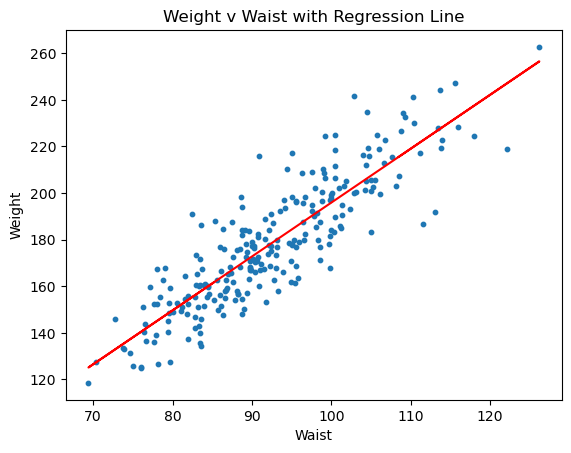

In [62]:
import matplotlib.pyplot as plt
%matplotlib inline
# .predict(X) After the model has been trained with .fit(), .predict() uses the learned slope and intercept to calculate # the predicted y value for every x value in your dataset. So internally it's just doing: Y_pred = slope × X + intercept
# for every waist measurement in X, giving you back a predicted weight for each one.
Y_pred = reg.predict(X)

plt.scatter(X, y, s = 10)
plt.plot(X, Y_pred, color='red')
plt.xlabel('Waist')
plt.ylabel('Weight')
plt.title ('Weight v Waist with Regression Line' )
plt.show()
# blue dots = actual values
# red lien  = regression line.
# some farway awat.. thats why line is 0.76 only... as R squared statistic...

#### 2). Multivariate Regression:
<ul>
<li>Load the bike_sharing.csv dataset.</li>
<li>Explore it and select features.</li>
<li>Use a standard scaler to fit your model and show your coefficients.</li>
<li>Use a stochastic gradient descent regressor and measure+compare results (MSE, MAE, RMSE).</li>
</ul>

In [63]:
bikes_df = pd.read_csv('bike_sharing.csv')
bikes_df.head()
# target is count - we want to predict the count
# more than 1 feature here... 
# some features are useful and some are not...

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [64]:
# get putput valeus and set tem as y
y = bikes_df.pop('count').values   # target values values puts it as an array
#pop off features that are not useful
# get rid of useless columns...
bikes_df.pop('casual') # dont' add value
bikes_df.pop('registered') # dont' add value
bikes_df.pop('instant') # don't need ID 
bikes_df.pop('dteday') # don't need datw time column either... so remove all

# X has x features now only...
X = bikes_df.values
X.shape

(731, 11)

In [65]:
# get names of colmns just t view...
bikes_df.columns

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')

In [66]:
# Ordinary Least Squares regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
# standard scaler  - std  = 1 and mean  = 0 >>> for fatse conversio in model
# without scaler some avlues woudl eb large and soke small
# so important to standard  / normalise
# build 
X_scal = StandardScaler().fit_transform(X) 

# build linear regresisn model
reg = LinearRegression().fit(X_scal, y)

# get scores of the mdoel
# {:.3f} = 3 decimal places
# {:.2f} = 3 decimal places
print(' R squared statistic: {:.3f}'.format(reg.score(X_scal, y)))
print(' Intercept: {:.2f}'.format(reg.intercept_))

# R squared statistic: 0.800
# Intercept: 4504.35

 R squared statistic: 0.800
 Intercept: 4504.35


In [67]:
#print out the weights for each feature inside our dataset...
# see whcih features matter the most - view the weights...
# zip pairs up two lists by element , like a zipper...
#  reg.coef_ is the slope and we have one per feature.... it is the "  w  " vector form the lecture equations
# reg,intercept is w[0] (the bias/intercept term)
# In Maths /statistics w[0] = intercept // in ML w]0] is called the bias
for i,j in zip(reg.coef_, bikes_df.columns):
    print(i,j)
    
# In multivariate regression you have one slope/coefficient per feature, so reg.coef_ is now a list rather than a single number. This loop lets you see:

# Which features have a large positive coefficient → strong positive influence on the target
# Which features have a large negative coefficient → strong negative influence
# Which features have a coefficient near zero → little influence on the target

# It's essentially a quick way to see which features matter most to your model.

565.8744533798854 season
1020.3507460886499 yr
-134.46199109612894 mnth
-86.69260451551597 holiday
138.36029286893617 weekday
55.95577694359886 workingday
-332.6955680380428 weathersit
371.14099460440514 temp
581.9065590011769 atemp
-145.01623946104408 hum
-198.07054397855825 windspeed


In [68]:
#Stochastic Gradient Descent Regressor
 # stochastic gradient descent
 # SGDRegressor is doing the same job as LinearRegression (finding the best weights/slopes) but using a different method to get there — Stochastic Gradient Descent, 
# number of times model will apss through the dataset... i.e. 50 times... tolerance = stop in case improvement is < 01e-3)
# max_iter=50    # passes through the full dataset 50 times (50 "epochs") -  but may stop sooner if it's converged.
# tol=1e-3       # stops early if improvement between passes drops below 0.001

# Instead of calculating the gradient on the full dataset each pass, it picks random individual samples to update the weights — this is exactly the gradient descent from your slides but applied one (or a few) random examples at a time rather than all n instances at once. It's noisier but much faster on large datasets.

from sklearn.linear_model import SGDRegressor
SGD = SGDRegressor(max_iter=50, tol=1e-3).fit(X_scal, y)
print(' R squared statistic: {:.3f}'.format(SGD.score(X_scal, y)))
print(' Intercept: {:.2f}'.format(SGD.intercept_[0]))

# R squared statistic: 0.800
# Intercept: 4501.94

 R squared statistic: 0.800
 Intercept: 4510.04


In [69]:
# print each co-efficient  for each feature
for i,j in zip(SGD.coef_, bikes_df.columns):
    print(i,j)
    
    # differenc ebetween linerar regression and stochastic is different as intercept is different
    # when low are better
    # Same as before — it's printing the coefficient (slope) for each feature, just now for the SGD model instead of the Linear Regression model.
# The interesting part is comparing these coefficients to the ones from LinearRegression:

# If the dataset is large enough, SGD should converge to roughly the same weights as ordinary Linear Regression
# But they'll rarely be exactly the same because SGD is stochastic (random) and iterative — it's approximating the # solution rather than solving it exactly
# The intercept difference your comment mentions is a good example of this — SGD gets close but not identical

# Think of it like this:

# LinearRegression = solving a maths problem with an exact formula, always same answer
# SGDRegressor = repeatedly making small educated guesses until you're close enough, slightly different each run due to randomness

# Same destination, different route — and SGD sometimes doesn't arrive at exactly the same spot.

552.344413680922 season
1022.8518773496822 yr
-124.40204125543251 mnth
-88.42856937099697 holiday
139.05439796470364 weekday
54.781642192685396 workingday
-333.4084649406954 weathersit
458.15556414562656 temp
505.94660756862095 atemp
-144.72284195868767 hum
-199.53518253858945 windspeed


In [70]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

# This is calculating three different ways to measure how wrong the model's predictions are — error metrics.
# root mean squred error function
def RMSE(y_true, y_pred): 
    return np.sqrt(mean_squared_error(y_true, y_pred))

# MAE — Mean Absolute Error
# average of |actual - predicted|
# Takes the difference between each prediction and actual value, ignores the sign, averages them
# Easy to interpret — "on average my predictions are off by X units"

print('MSE: %.2f'
      % mean_squared_error(y, SGD.predict(X_scal)))

# MSE — Mean Squared Error - average of (actual - predicted)²
# Same but squares the errors before averaging
# This is the L₂ loss from your slides!
# Squaring means **big errors are penalised much more** than small ones
# Harder to interpret because the units are squared (e.g. kg²)

print('MAE: %.2f'
      % mean_absolute_error(y, SGD.predict(X_scal)))

# RMSE — Root Mean Squared Error - √(MSE)
# Just the square root of MSE
# Brings units back to normal (e.g. kg instead of kg²)
# Still penalises big errors heavily like MSE, but now interpretable like MAE
# Most commonly used in practice — notice sklearn doesn't include it built-in, which is why a custom function is defined:

print('RMSE: %.2f'
      % RMSE(y, SGD.predict(X_scal)))

# MSE: 748841.45
# MAE: 644.63
# RMSE: 865.36

# | Metric | Penalises big errors? | Easy to interpret? |
# |---      |---                    |---             |
# | MAE | No, treats all errors equally | Yes |
# | MSE | Yes, heavily                  | No (squared units) |
# | RMSE | Yes, heavily                 | Yes |

# tell su show good the model is...
# R² tells you "how well does the model explain the variance in the data" — a relative measure between 0 and 1.
# But MAE/MSE/RMSE tell you how wrong your predictions are in actual units — much more practical. For example:

# R² = 0.80 sounds good but doesn't tell you much concretely
# RMSE = 50kg tells you your predictions are off by ~50kg on average — now you can judge if that's acceptable or not

# So together they give you a fuller picture of model performance:

# R² → how well the model fits overall
# RMSE/MAE → how big the errors are in real terms

MSE: 748906.86
MAE: 644.98
RMSE: 865.39


#### 3). Logistic Regression:
<ul>
<li>Load the AthleteSelection.csv dataset.</li>
<li>Explore it and select features.</li>
<li>Fit a logistic regression model and show coefficients + r squared statistic.</li>
<li>Compare to results with standard scaler.</li>
</ul>

In [71]:
athlete_pd = pd.read_csv('AthleteSelection.csv')
# sort bvased on agility
# won't do any implacment - no replacement for any other columns
# sorted in standing order...
athlete_pd.sort_values('Agility',inplace = True, ascending = False)
athlete_pd.head(5)
# selected is target column

,Athlete,Speed,Agility,Selected
16,x17,5.40,9.50,Yes
13,x14,5.75,8.75,Yes
12,x13,8.25,8.50,Yes
3,x4,3.25,8.25,No
18,x19,7.50,8.00,Yes


In [72]:
# y is target value and an array using values...
y = athlete_pd.pop('Selected').values
# don't need athlete feature.. will remove using .pop
athlete_pd.pop('Athlete')  # get rid of ids from dataset
X = athlete_pd.values
X.shape

(20, 2)

In [73]:
from sklearn.linear_model import LogisticRegression
# create an instance of LogReg model...
# liblinear is just the algorithm use dinternally to find the best weights... this is a godo default for small datasets
 #for log reg no longer R squred... it is now accuracy (% of correctly classified examples...)
lreg = LogisticRegression(solver='liblinear').fit(X, y)
print(' R squared statistic: {:.2f}'.format(lreg.score(X, y)))

# Still coefficients/weights per feature like before
# But now coef_ is 2D (notice [0][0] instead of just [0]) because logistic regression is built to handle **multiple # classes**# meas retrieving the co-eff for first feature... slope of first feature
# 2nd is co-eff of agility... slopt and frit column indexing of columns....
print(' Speed: {:.2f} Agility: {:.2f}'.format(lreg.coef_[0][0],
                                              lreg.coef_[0][1]))
#  same bias / intercept as before
print(' Intercept: {:.2f}'.format(lreg.intercept_[0]))


# So the big picture shift here is you've moved from predicting a number to predicting which class/category something # belongs to — that's the fundamental difference between regression and classification.

 # squared statistic: 0.85 ## closer to 1  = better fit for data / further away doesn't work wel for data
 # Speed: 0.38 Agility: -0.05
 # Intercept: -1.61

 R squared statistic: 0.85
 Speed: 0.38 Agility: -0.05
 Intercept: -1.61


In [74]:
# Normalise the values and see the impact on performance on the training data
from sklearn.preprocessing import StandardScaler
# normalisatio very important as some values so high and some so low...
 #so need normalisatin
 X_scal = StandardScaler().fit_transform(X)
# trai model.. using descriptiev features of x and target features of y
lreg = LogisticRegression(solver='liblinear').fit(X_scal, y)


print(' R squared statistic: {:.2f}'.format(lreg.score(X_scal, y)))
print(' Speed: {:.2f} Agility: {:.2f}'.format(lreg.coef_[0][0],lreg.coef_[0][1]))
print(' Intercept: {:.2f}'.format(lreg.intercept_[0]))

# R squared statistic: 0.95 >> # close to 1 model performign wel on data
#  Speed: 1.76 Agility: 0.83 >> 
#  Intercept: -0.37 >> intercept cecresed  >> scaling afected Log reg model >. important to do normalisation

IndentationError: unexpected indent (588060107.py, line 5)

In [ ]:
# means want first 5 rows inside this arrary.... after w applyied the scaler...
# scaling is very important...
X_scal[:5]

array([[ 0.37882399,  1.6692244 ],
       [ 0.5843874 ,  1.3274037 ],
       [ 2.05269746,  1.21346347],
       [-0.88392265,  1.09952324],
       [ 1.61220444,  0.98558301]])

#### 4). SVMs:
<ul>
<li>Load libraries and the HotelRevHelpfulnessV2.csv dataset.</li>
<li>Explore it, get an overview of overall, positive and negative samples, and select features.</li>
<li>Use a standard scaler and create a test/train split.</li>
<li>Fit your model and make predictions on a linear kernel.</li>
<li>Measure accuracy and create a classification report</li>
</ul>

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC # import svc mdoel form sklearn 
from sklearn.model_selection import train_test_split # improt model selectin to use tra6tn and test fucntino
from sklearn.metrics import classification_report # metrics we are suing  /CM amd accuracyh score
from sklearn.metrics import confusion_matrix, accuracy_score # don't need to define f1, recision etc as already part of classificiont report imported earlier...

In [ ]:
hotel_rev = pd.read_csv('HotelRevHelpfulnessV2.csv')
hotel_rev.head()

,aveHelpfulnessRatioUser,stdevHelpfulnessRatioUser,pcReviewsExceedMinHelpfulnessSupport,numReviewsUser,numReviewsHotel,ratingUser,numberSubRatingsUser,subRatingMeanUser,subRatingStdevUser,aveRatingUser,...,completeness_2,completeness_3,numberTermsEntry,percentageAlphaCharsEntry,fractionUpperCaseCharsEntry,fractionYouVsIEntry,numberTermsSummaryQuote,percentageAlphaCharsSummaryQuote,fractionUpperCaseCharsSummaryQuote,reviewHelpfulness
0,1.000000,0.000000,0.666667,3,16,5,4,4.000000,0.000000,4.333333,...,0,1,182,0.788474,0.025703,0.500000,6,0.815789,0.096774,1
1,0.772487,0.377321,0.500000,12,233,5,0,0.000000,0.000000,4.333333,...,0,0,158,0.791888,0.012594,0.500000,1,1.000000,0.083333,1
2,0.715473,0.300437,0.833333,12,302,4,7,3.714286,0.755929,4.166667,...,0,3,59,0.799639,0.024831,0.333333,4,0.828571,0.034483,0
3,0.521250,0.481675,0.222222,36,6,1,4,1.000000,0.000000,3.527778,...,0,0,95,0.782212,0.029155,0.500000,2,0.800000,0.062500,0
4,0.603175,0.246926,1.000000,2,271,3,0,0.000000,0.000000,3.500000,...,0,0,43,0.805128,0.028662,0.000000,1,1.000000,0.142857,0


In [ ]:
# oritn how many sa els are inside to see how many positive and how manyh negative
 # get # of samples inside the dataframe
n = hotel_rev.shape[0]
 # cont how much positive and how much negative
 # target column is review helpfulness... 1  = helpful 0 = not helpful...
np = hotel_rev['reviewHelpfulness'].sum() # use sum to get number of ones....!
nn = n - np
print('{} Samples'.format(n))
print('{} Positive \n{} Negative'.format(np,nn))

# 486 Samples
# 308 Positive 
# 178 Negative

486 Samples
308 Positive 
178 Negative


In [ ]:
# creat y array for target values
# all colmsn are numerical... no categorocal and no oen is not important...
# so use all columns / features...
y = hotel_rev.pop('reviewHelpfulness').values
# take values as they are 
Xraw = hotel_rev.values
scaler = StandardScaler()
# scale using for_transfor function
X = scaler.fit_transform(Xraw)
# split into train and test....
# test size 1/3 means if 10 samples >>> trainnig will be 2/3 8 test will be 1/3 
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=1/3)
print("X_test shape: ",X_test.shape)
print("X_train shape: ",X_train.shape)
print("y_test shape: ",y_test.shape)
print("y_train shape: ",y_train.shape)


# X_test shape:  (162, 23)
# X_train shape:  (324, 23)
# y_test shape:  (162,)
# y_train shape:  (324,)

X_test shape:  (162, 23)
X_train shape:  (324, 23)
y_test shape:  (162,)
y_train shape:  (324,)


In [ ]:
# create an instance for model...
# will sue linear and c=1
svm = SVC(kernel = 'linear',C=1)   
# traing it using .fit
hotel_rev_SVM = svm.fit(X_train, y_train)
# test wiht ruo test data... using .predict
y_dash = hotel_rev_SVM.predict(X_test)

In [ ]:
# calculate accuracy
# y_dash is predicted valeus fomr svm model
acc = accuracy_score(y_test, y_dash)
print("Accuracy: {0:.2f}".format(acc)) 
confusion = confusion_matrix(y_test, y_dash)
print("Confusion matrix:\n{}".format(confusion)) 

# Accuracy: 0.69
# Confusion matrix:
# [[30 32]
#  [18 82]]

Accuracy: 0.69
Confusion matrix:
[[30 32]
 [18 82]]


In [ ]:

# use confusio matrix to check actai numebrs predictyed and incorectly predicted...
# if didn't sue target names not helpful this means this is the zero and helpful means this is = 1
report = classification_report(y_test, y_dash, target_names = ['Not Helpful','Helpful'])

print("Report:\n{}".format(report)) 




Report:
              precision    recall  f1-score   support

 Not Helpful       0.62      0.48      0.55        62
     Helpful       0.72      0.82      0.77       100

    accuracy                           0.69       162
   macro avg       0.67      0.65      0.66       162
weighted avg       0.68      0.69      0.68       162

